# Diabetes Risk Prediction — End-to-End ML Mini Project
**Goal:** predict whether a patient is likely to have diabetes from clinical measurements, following the full ML lifecycle:
1. Problem framing → 2. Data selection → 3. EDA → 4. Data preparation → 5. Algorithm selection → 6. Tuning → 7. Evaluation → 8. Explainability → 9. Save model → 10. Gradio app

> ⚠️ Educational project only. Not a medical device.

**Success metric:** in screening, a missed case (false negative) costs more than a false alarm, so we focus on **recall** and **PR-AUC**, not accuracy.

## 0. Setup

In [3]:
!pip -q install gradio

In [4]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, average_precision_score, precision_recall_curve,
                             recall_score, precision_score, f1_score)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## 1. Data selection
**Dataset:** Pima Indians Diabetes Database (Kaggle: `uciml/pima-indians-diabetes-database`), 768 rows, 8 numeric features, binary target `Outcome`.
Small enough for fast iteration, but contains a real data-quality trap (hidden missing values), which makes it good for a portfolio.

In [5]:
COLS = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]
try:
    import kagglehub
    path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
    df = pd.read_csv(os.path.join(path, "diabetes.csv"))
    print("Loaded from Kaggle")
except Exception as e:
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    df = pd.read_csv(url, header=None, names=COLS)
    print("Loaded from public mirror (Kaggle download unavailable)")
df.head()

Loaded from public mirror (Kaggle download unavailable)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Exploratory data analysis

In [7]:
print("Shape:", df.shape)
print("\nClass balance:\n", df["Outcome"].value_counts(normalize=True).round(3))
print("\nDuplicates:", df.duplicated().sum())
df.describe().T

Shape: (768, 9)

Class balance:
 Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Duplicates: 0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [8]:
# Hidden missing values: physiologically impossible zeros
zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
print((df[zero_cols] == 0).sum().to_frame("zeros_count").assign(pct=lambda d: (d.zeros_count/len(df)*100).round(1)))

               zeros_count   pct
Glucose                  5   0.7
BloodPressure           35   4.6
SkinThickness          227  29.6
Insulin                374  48.7
BMI                     11   1.4


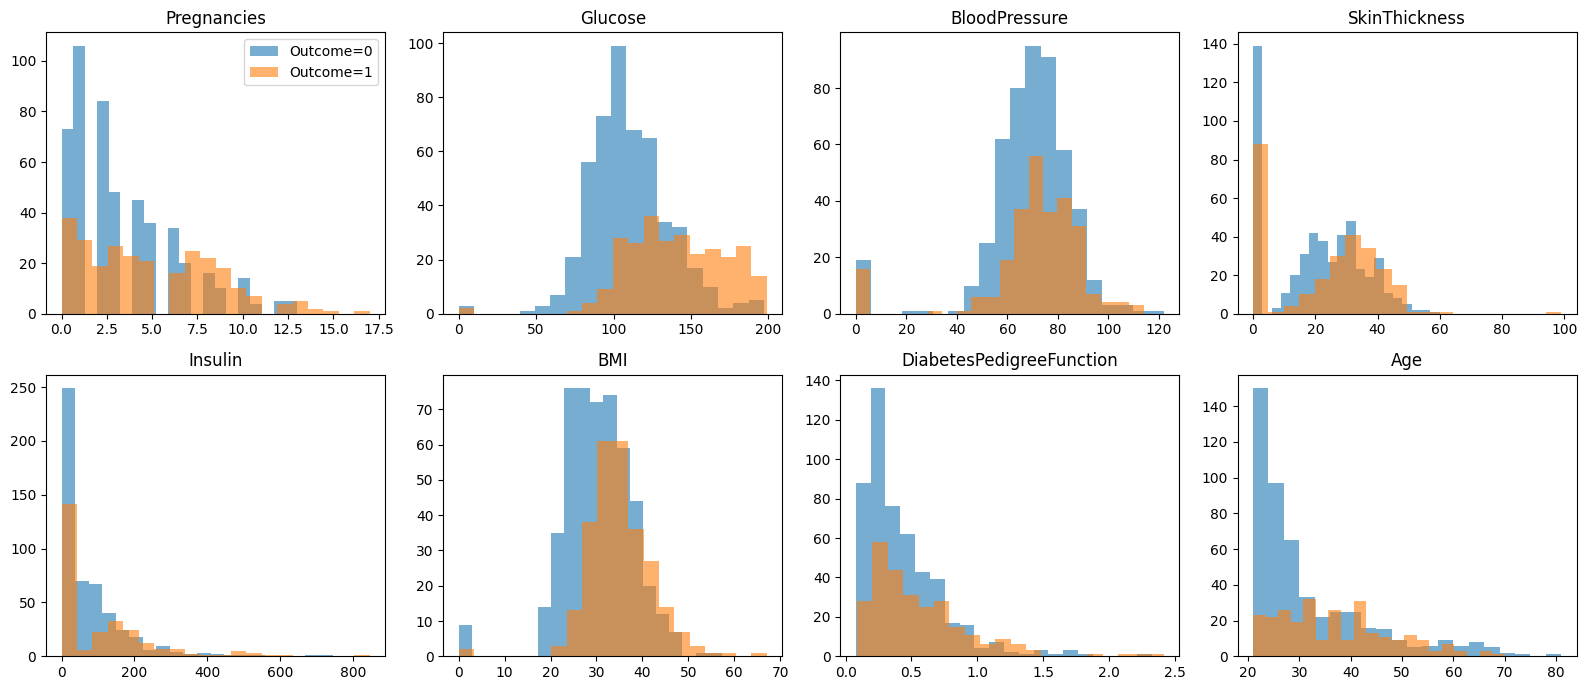

Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065
Name: Outcome, dtype: float64


In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), COLS[:-1]):
    for label, g in df.groupby("Outcome"):
        ax.hist(g[col], bins=20, alpha=0.6, label=f"Outcome={label}")
    ax.set_title(col)
axes[0,0].legend()
plt.tight_layout(); plt.show()

print(df.corr()["Outcome"].drop("Outcome").sort_values(ascending=False).round(3))

**Findings to note in your README:**
- ~35% positive class → mild imbalance, so use stratified splits and recall/PR-AUC.
- Zeros in Glucose, BloodPressure, SkinThickness, Insulin, BMI are missing values, not real measurements → convert to `NaN` and impute.
- Glucose, BMI, Age are among the strongest signals.

## 3. Data preparation
Rules: **split first** (avoid leakage), and put imputation + scaling **inside a Pipeline** so they are learned from training folds only.

In [9]:
df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

X = df_clean.drop(columns="Outcome")
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape, y_train.mean().round(3), y_test.mean().round(3))

def make_pipe(model):
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", model),
    ])

(614, 8) (154, 8) 0.349 0.351


## 4. Algorithm selection
Start from a dummy baseline, then compare simple → complex models with **stratified 5-fold CV** on the training set only.

In [10]:
models = {
    "Dummy (baseline)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM (RBF)": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"recall": "recall", "precision": "precision", "f1": "f1",
           "roc_auc": "roc_auc", "pr_auc": "average_precision"}

rows = []
for name, m in models.items():
    res = cross_validate(make_pipe(m), X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name, **{k: f"{res[f'test_{k}'].mean():.3f} ± {res[f'test_{k}'].std():.3f}" for k in scoring}})
pd.DataFrame(rows).set_index("model")

,recall,precision,f1,roc_auc,pr_auc
model,,,,,
Dummy (baseline),0.374 ± 0.028,0.390 ± 0.031,0.382 ± 0.029,0.531 ± 0.022,0.365 ± 0.014
Logistic Regression,0.701 ± 0.039,0.649 ± 0.026,0.672 ± 0.013,0.844 ± 0.016,0.748 ± 0.056
SVM (RBF),0.762 ± 0.052,0.637 ± 0.062,0.690 ± 0.029,0.837 ± 0.031,0.709 ± 0.057
Random Forest,0.593 ± 0.025,0.711 ± 0.066,0.645 ± 0.033,0.823 ± 0.028,0.705 ± 0.052
Gradient Boosting,0.598 ± 0.031,0.672 ± 0.051,0.631 ± 0.013,0.820 ± 0.015,0.713 ± 0.045


## 5. Hyperparameter tuning
Tune the strongest tree model and compare it with the untuned Logistic Regression, selecting by CV PR-AUC.

In [12]:
param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [3, 5, 7, None],
    "model__min_samples_leaf": [1, 3, 5, 10],
    "model__max_features": ["sqrt", 0.5, None],
}
search = RandomizedSearchCV(
    make_pipe(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
    param_dist, n_iter=20, scoring="average_precision", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train, y_train)
print("Best RF params:", search.best_params_)
print("Best RF CV PR-AUC:", round(search.best_score_, 3))

lr_pr = cross_validate(make_pipe(models["Logistic Regression"]), X_train, y_train, cv=cv,
                       scoring={"pr": "average_precision"})["test_pr"].mean()
print("Logistic Regression CV PR-AUC:", round(lr_pr, 3))

final_model = search.best_estimator_ if search.best_score_ >= lr_pr else make_pipe(models["Logistic Regression"])
final_model.fit(X_train, y_train)
print("Selected:", final_model.named_steps["model"].__class__.__name__)

Best RF params: {'model__n_estimators': 300, 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 3}
Best RF CV PR-AUC: 0.743
Logistic Regression CV PR-AUC: 0.748
Selected: LogisticRegression


## 6. Evaluation
The decision threshold is chosen from **cross-validated predictions on the training set** (target recall ≥ 0.80), so the test set stays untouched until the final check.

Chosen threshold: 0.406
ROC-AUC: 0.813 | PR-AUC: 0.673
              precision    recall  f1-score   support

 No diabetes       0.87      0.67      0.76       100
    Diabetes       0.57      0.81      0.67        54

    accuracy                           0.72       154
   macro avg       0.72      0.74      0.71       154
weighted avg       0.77      0.72      0.73       154



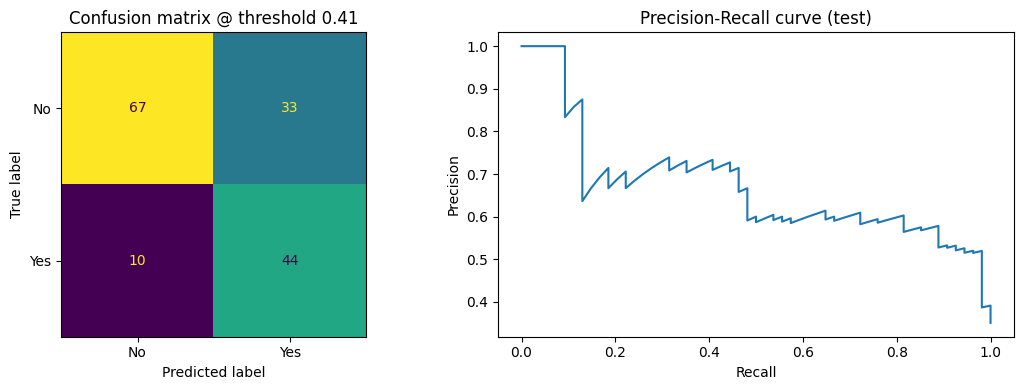

In [16]:
oof = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)
ok = np.where(rec[:-1] >= 0.80)[0]
THRESHOLD = float(thr[ok[-1]]) if len(ok) else 0.5   # highest threshold that still gives recall >= 0.80
print("Chosen threshold:", round(THRESHOLD, 3))

proba = final_model.predict_proba(X_test)[:, 1]
pred = (proba >= THRESHOLD).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3), "| PR-AUC:", round(average_precision_score(y_test, proba), 3))
print(classification_report(y_test, pred, target_names=["No diabetes", "Diabetes"]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["No", "Yes"]).plot(ax=ax[0], colorbar=False)
ax[0].set_title(f"Confusion matrix @ threshold {THRESHOLD:.2f}")
p, r, _ = precision_recall_curve(y_test, proba)
ax[1].plot(r, p); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].set_title("Precision-Recall curve (test)")
plt.tight_layout(); plt.show()

## 7. Explainability

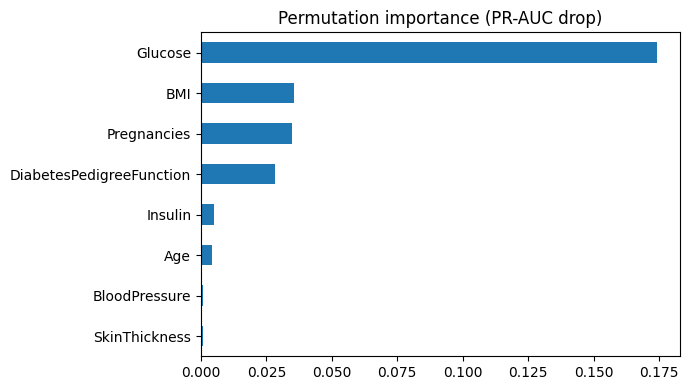

In [14]:
imp = permutation_importance(final_model, X_test, y_test, scoring="average_precision",
                             n_repeats=20, random_state=RANDOM_STATE)
imp_df = pd.Series(imp.importances_mean, index=X.columns).sort_values()
imp_df.plot.barh(figsize=(7, 4), title="Permutation importance (PR-AUC drop)")
plt.tight_layout(); plt.show()

Check: do the top features (Glucose, BMI, Age) match medical intuition? Write this reasoning in your model card.

## 8. Save the model

In [17]:
joblib.dump({"pipeline": final_model, "threshold": THRESHOLD, "features": list(X.columns)}, "diabetes_model.joblib")
print("Saved diabetes_model.joblib")

Saved diabetes_model.joblib


## 9. Gradio app
Inputs of `0` for Glucose, BloodPressure, SkinThickness, Insulin or BMI are treated as **unknown** (same as in training).
In Colab, `share=True` also gives you a public link you can put in your portfolio (it expires after about a week).

In [18]:
import gradio as gr

bundle = joblib.load("diabetes_model.joblib")
pipe, thr_, feats = bundle["pipeline"], bundle["threshold"], bundle["features"]
ZERO_AS_MISSING = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

def predict(pregnancies, glucose, bp, skin, insulin, bmi, dpf, age):
    row = pd.DataFrame([[pregnancies, glucose, bp, skin, insulin, bmi, dpf, age]], columns=feats)
    row[ZERO_AS_MISSING] = row[ZERO_AS_MISSING].replace(0, np.nan)
    p = float(pipe.predict_proba(row)[0, 1])
    flag = p >= thr_
    verdict = "⚠️ Higher risk — consider a clinical check" if flag else "✅ Lower risk"
    return {"Diabetes": p, "No diabetes": 1 - p}, f"{verdict}\n(risk score {p:.0%}, decision threshold {thr_:.0%})"

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Slider(0, 17, value=2, step=1, label="Pregnancies"),
        gr.Slider(0, 200, value=120, label="Glucose (mg/dL, 0 = unknown)"),
        gr.Slider(0, 122, value=70, label="Blood pressure (mm Hg, 0 = unknown)"),
        gr.Slider(0, 99, value=20, label="Skin thickness (mm, 0 = unknown)"),
        gr.Slider(0, 846, value=80, label="Insulin (µU/mL, 0 = unknown)"),
        gr.Slider(0, 67, value=28, label="BMI (0 = unknown)"),
        gr.Slider(0.05, 2.5, value=0.4, label="Diabetes pedigree function"),
        gr.Slider(21, 81, value=33, step=1, label="Age"),
    ],
    outputs=[gr.Label(label="Prediction"), gr.Textbox(label="Interpretation")],
    title="Diabetes Risk Predictor (educational demo)",
    description="Trained on the Pima Indians Diabetes dataset. Not medical advice.",
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8fbe3b5c293376ea9e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
